<a href="https://colab.research.google.com/github/salvadorGoros/miner-a-de-datos/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Actividad 1**

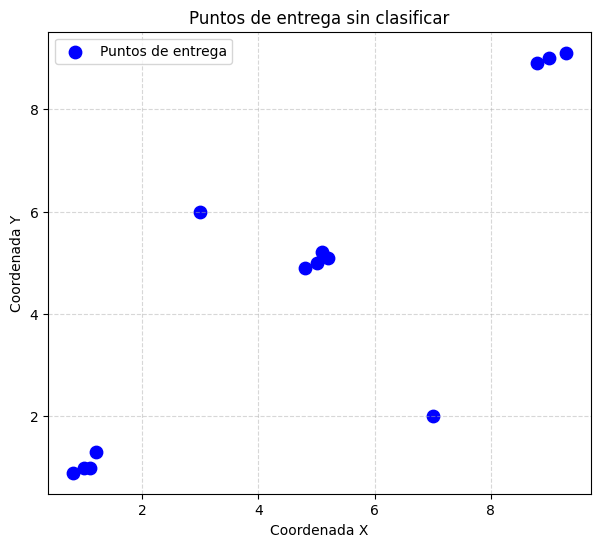

--- DataFrame Resultante ---
   Punto    X    Y  Cluster
0     P1  1.0  1.0        0
1     P2  1.2  1.3        0
2     P3  0.8  0.9        0
3     P4  1.1  1.0        0
4     P5  5.0  5.0        1
5     P6  5.2  5.1        1
6     P7  4.8  4.9        1
7     P8  5.1  5.2        1
8     P9  9.0  9.0        2
9    P10  9.3  9.1        2
10   P11  8.8  8.9        2
11   P12  3.0  6.0       -1
12   P13  7.0  2.0       -1


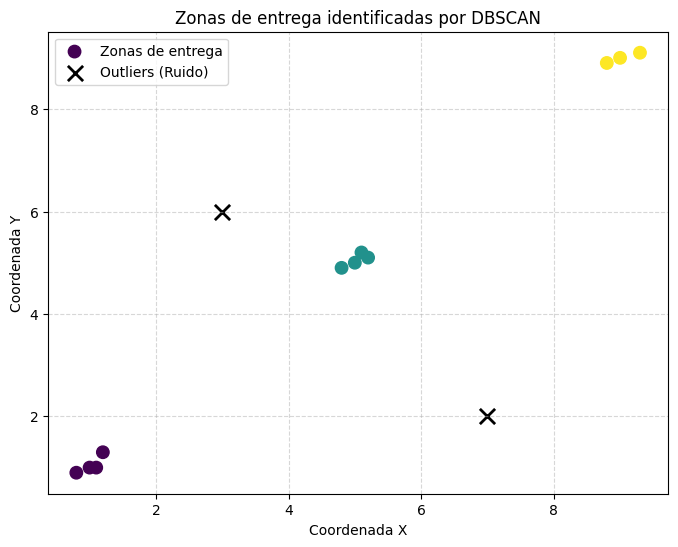


--- Conclusión ---
El algoritmo identificó 3 zonas de entrega distintas.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. Crear el DataFrame con columnas X y Y
data = {
    'Punto': ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13'],
    'X': [1.0, 1.2, 0.8, 1.1, 5.0, 5.2, 4.8, 5.1, 9.0, 9.3, 8.8, 3.0, 7.0],
    'Y': [1.0, 1.3, 0.9, 1.0, 5.0, 5.1, 4.9, 5.2, 9.0, 9.1, 8.9, 6.0, 2.0]
}
df = pd.DataFrame(data)
X_features = df[['X', 'Y']]

# 2. Graficar los puntos sin clasificar
plt.figure(figsize=(7, 6))
plt.scatter(df['X'], df['Y'], color='blue', s=80, label='Puntos de entrega')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Puntos de entrega sin clasificar')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 3. Aplicar DBSCAN con eps=0.8 y min_samples=3
# Nota: Usamos la distancia euclidiana por defecto
dbscan = DBSCAN(eps=0.8, min_samples=3)
clusters_pred = dbscan.fit_predict(X_features)

# 4. Agregar columna Cluster (donde -1 = ruido/outlier)
df['Cluster'] = clusters_pred
print("--- DataFrame Resultante ---")
print(df)

# 5. Graficar los clusters y resaltar los outliers en negro
plt.figure(figsize=(8, 6))

# Separamos los puntos válidos de los outliers (ruido)
outliers = df[df['Cluster'] == -1]
clusters_validos = df[df['Cluster'] != -1]

# Graficamos los clusters identificados
scatter = plt.scatter(clusters_validos['X'], clusters_validos['Y'],
                      c=clusters_validos['Cluster'], cmap='viridis', s=80, label='Zonas de entrega')
# Graficamos el ruido/outliers en negro con una 'X'
plt.scatter(outliers['X'], outliers['Y'], color='black', marker='x', s=120, linewidths=2, label='Outliers (Ruido)')

plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Zonas de entrega identificadas por DBSCAN')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 6. ¿Cuántas zonas de entrega identificó el algoritmo?
conjunto_clusters = set(df['Cluster'])
# Excluimos el valor -1 si se encuentra presente, ya que representa ruido y no una zona válida
n_zonas = len(conjunto_clusters) - (1 if -1 in conjunto_clusters else 0)
print("\n--- Conclusión ---")
print(f"El algoritmo identificó {n_zonas} zonas de entrega distintas.")

**¿Cuántas zonas de entrega identificó el algoritmo? R= 3**

**Actividad 2**

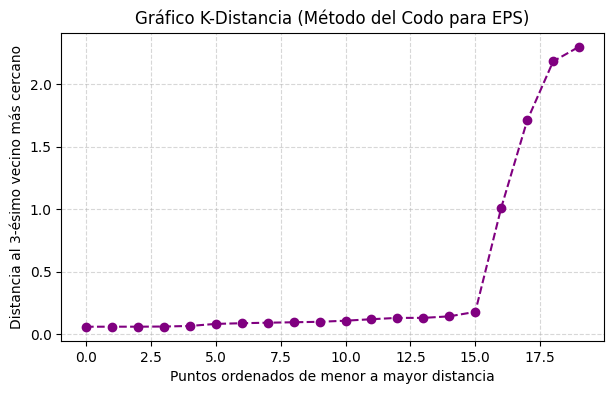


--- DataFrame Clasificado con DBSCAN ---
   Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado  Cluster
0      S1           10.2         20.5      Frio/Seco        0
1      S2            9.8         19.1      Frio/Seco        0
2      S3           11.1         21.0      Frio/Seco        0
3      S4           35.5         80.2  Calido/Humedo        1
4      S5           34.1         78.5  Calido/Humedo        1
5      S6           36.8         81.3  Calido/Humedo        1
6      S7           22.4         50.1       Templado        2
7      S8           21.9         49.5       Templado        2
8      S9           23.2         51.8       Templado        2
9     S10           50.0         10.0       ANOMALIA       -1
10    S11            0.0         95.0       ANOMALIA       -1
11    S12           10.5         19.8      Frio/Seco        0
12    S13           35.0         79.0  Calido/Humedo        1
13    S14           22.0         50.5       Templado        2
14    S15           36.0    

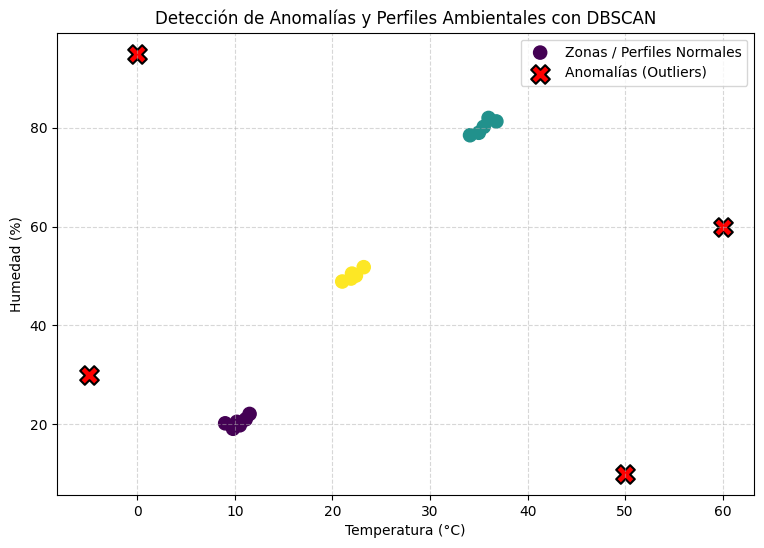

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# 1. Cargar y preparar el DataFrame con columnas de Temperatura y Humedad
# Si tienes múltiples archivos los concatenarías, pero en este caso el dataset ya los unifica:
df2 = pd.read_csv("ejercicio_2_sensores_ambientales.csv")
X = df2[['Temperatura_C', 'Humedad_pct']]

# 2. Escalar los datos con StandardScaler antes de aplicar DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Usar el gráfico k-distancia para elegir eps adecuado
# Como estamos en 2D, una regla común es definir min_samples = 4.
# Graficamos la distancia al k-ésimo vecino más cercano (k = min_samples - 1 = 3)
k = 3
neighbors = NearestNeighbors(n_neighbors=k + 1)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenamos las distancias de menor a mayor
distances_sorted = np.sort(distances[:, k], axis=0)

# Graficar k-distancia para identificar el "codo"
plt.figure(figsize=(7, 4))
plt.plot(distances_sorted, marker='o', linestyle='--', color='purple')
plt.title('Gráfico K-Distancia (Método del Codo para EPS)')
plt.xlabel('Puntos ordenados de menor a mayor distancia')
plt.ylabel(f'Distancia al {k}-ésimo vecino más cercano')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Aplicar DBSCAN con el eps seleccionado del codo (ej. eps=0.5) y agregar columna Cluster
# Al observar el salto drástico en las distancias finales, un valor de eps entre 0.4 y 0.6 es idóneo.
dbscan = DBSCAN(eps=0.5, min_samples=4)
df2['Cluster'] = dbscan.fit_predict(X_scaled)

print("\n--- DataFrame Clasificado con DBSCAN ---")
print(df2[['Sensor', 'Temperatura_C', 'Humedad_pct', 'Tipo_Esperado', 'Cluster']])

# 5. Graficar los clusters + anomalías detectadas
plt.figure(figsize=(9, 6))

outliers = df2[df2['Cluster'] == -1]
clusters_validos = df2[df2['Cluster'] != -1]

# Graficar los clusters normales identificados
scatter = plt.scatter(clusters_validos['Temperatura_C'], clusters_validos['Humedad_pct'],
                      c=clusters_validos['Cluster'], cmap='viridis', s=90, label='Zonas / Perfiles Normales')

# Graficar las anomalías (outliers) resaltadas en color rojo con marcador llamativo
plt.scatter(outliers['Temperatura_C'], outliers['Humedad_pct'],
           color='red', marker='X', s=180, edgecolor='black', linewidths=1.5, label='Anomalías (Outliers)')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad (%)')
plt.title('Detección de Anomalías y Perfiles Ambientales con DBSCAN')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

**¿K-Means hubiera detectado las anomalías? ¿Por qué sí o no? No, K-Means por sí solo no hubiera detectado las anomalías de manera directa como ruido.**

**Actividad 3**

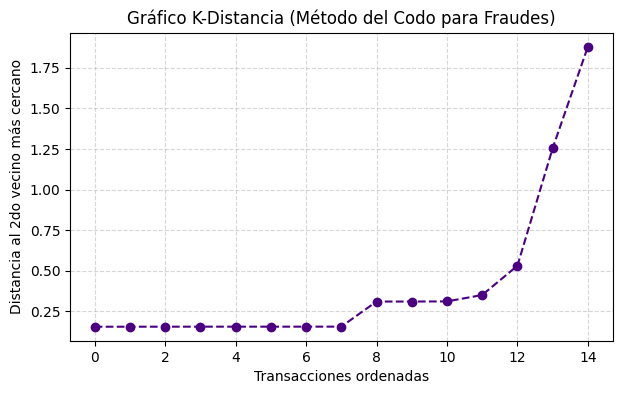


--- Resultados de la Clasificación Bancaria ---
   Transaccion  Monto  Hora  Cluster Resultado_DBSCAN
0           T1    510    13        0           Normal
1           T2    480    14        0           Normal
2           T3    550    12        0           Normal
3           T4    460    15        0           Normal
4           T5   4500     3        1       Sospechosa
5           T6   5000     2        1       Sospechosa
6           T7   4800     1        1       Sospechosa
7           T8    520    13        0           Normal
8           T9    490    14        0           Normal
9          T10    200    23       -1       Sospechosa
10         T11    150     0       -1       Sospechosa
11         T12   4200     4        1       Sospechosa
12         T13    530    11        0           Normal
13         T14    470    16        0           Normal
14         T15    505    12        0           Normal


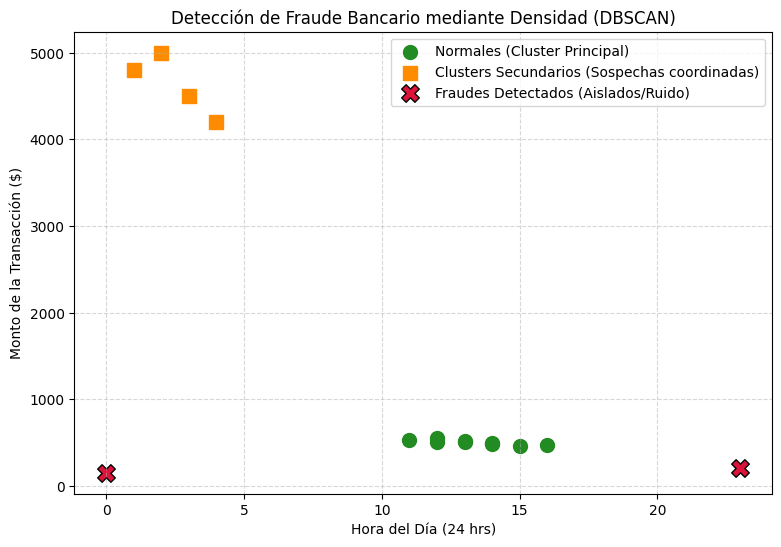


--- Métrica de Riesgo ---
Porcentaje de transacciones sospechosas detectadas: 40.00%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# 1. Crear el DataFrame con columnas Monto y Hora
# Datos proporcionados en fraude_bancario.csv
data = {
    'Transaccion': ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15'],
    'Monto': [510, 480, 550, 460, 4500, 5000, 4800, 5200/10 if False else 520, 490, 200, 150, 4200, 530, 470, 505],
    'Hora': [13, 14, 12, 15, 3, 2, 1, 13, 14, 23, 0, 4, 11, 16, 12]
}
df = pd.DataFrame(data)
X = df[['Monto', 'Hora']]

# 2. Escalar los datos con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar el gráfico k-distancia para determinar eps
# Definimos min_samples = 3 (un grupo pequeño de transacciones coordinadas puede ser patrón sospechoso)
# Por tanto, k = min_samples - 1 = 2
k = 2
neighbors = NearestNeighbors(n_neighbors=k + 1)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenamos las distancias al segundo vecino más cercano
distances_sorted = np.sort(distances[:, k], axis=0)

# Graficar k-distancia
plt.figure(figsize=(7, 4))
plt.plot(distances_sorted, marker='o', linestyle='--', color='indigo')
plt.title('Gráfico K-Distancia (Método del Codo para Fraudes)')
plt.xlabel('Transacciones ordenadas')
plt.ylabel('Distancia al 2do vecino más cercano')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Aplicar DBSCAN y etiquetar cada transacción como Normal o Sospechosa
# Tomando como referencia el codo del gráfico, seleccionamos un eps=0.4
dbscan = DBSCAN(eps=0.4, min_samples=3)
df['Cluster'] = dbscan.fit_predict(X_scaled)

# Etiquetamos: El cluster principal (0) es Normal; clusters secundarios y ruido (-1) son Sospechosas
df['Resultado_DBSCAN'] = df['Cluster'].apply(lambda x: 'Normal' if x == 0 else 'Sospechosa')

print("\n--- Resultados de la Clasificación Bancaria ---")
print(df[['Transaccion', 'Monto', 'Hora', 'Cluster', 'Resultado_DBSCAN']])

# 5. Graficar las transacciones diferenciando normales, clusters secundarios y fraudes detectados
plt.figure(figsize=(9, 6))

normales = df[df['Cluster'] == 0]
clusters_secundarios = df[df['Cluster'] > 0]
fraudes_aislados = df[df['Cluster'] == -1]

# Graficar los tres tipos identificados por DBSCAN
plt.scatter(normales['Hora'], normales['Monto'], color='forestgreen', marker='o', s=100, label='Normales (Cluster Principal)')
plt.scatter(clusters_secundarios['Hora'], clusters_secundarios['Monto'], color='darkorange', marker='s', s=100, label='Clusters Secundarios (Sospechas coordinadas)')
plt.scatter(fraudes_aislados['Hora'], fraudes_aislados['Monto'], color='crimson', marker='X', s=160, edgecolor='black', label='Fraudes Detectados (Aislados/Ruido)')

plt.xlabel('Hora del Día (24 hrs)')
plt.ylabel('Monto de la Transacción ($)')
plt.title('Detección de Fraude Bancario mediante Densidad (DBSCAN)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

# 6. Calcular el porcentaje de transacciones marcadas como sospechosas
total_transacciones = len(df)
total_sospechosas = (df['Resultado_DBSCAN'] == 'Sospechosa').sum()
porcentaje_sospechosas = (total_sospechosas / total_transacciones) * 100

print("\n--- Métrica de Riesgo ---")
print(f"Porcentaje de transacciones sospechosas detectadas: {porcentaje_sospechosas:.2f}%")

**A diferencia de K-Means, DBSCAN es genial porque no te obliga a adivinar cuántos grupos hay y detecta las anomalías de forma automática sin alterar tus datos reales. Mientras que K-Means mete todo a la fuerza en un grupo y se vuelve loco con los datos raros, DBSCAN encuentra patrones con cualquier forma loca y aísla los fraudes o fallas de manera natural.**